In [1]:
%pwd
%cd /home/jovyan/work/COVID/results
%pwd

/home/jovyan/work/COVID/results


'/home/jovyan/work/COVID/results'

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# square root transformed expression
adata = sc.read_h5ad("../COVID_macrophage_scVI.h5ad")
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

In [4]:
adata.X

<56861x26571 sparse matrix of type '<class 'numpy.float32'>'
	with 91567407 stored elements in Compressed Sparse Row format>

In [5]:
adata.layers['scvi_normalized']

array([[6.9758422e-03, 7.4520791e-03, 1.1651978e-03, ..., 5.2742059e-03,
        3.7222058e-03, 9.4407630e-01],
       [4.1575707e-02, 2.2634983e-03, 5.7472144e-03, ..., 6.3442159e-03,
        1.0290076e-03, 5.0898129e-01],
       [3.2675879e-03, 1.3976113e-02, 1.5390029e-03, ..., 1.0210078e-02,
        2.4600960e-03, 2.7418169e-01],
       ...,
       [2.0552961e-02, 6.0726231e-01, 4.7763395e-03, ..., 2.2359105e-02,
        1.8138409e-02, 3.5400007e-02],
       [2.3764938e-03, 7.2945899e-01, 4.2797721e-04, ..., 2.6130341e-03,
        4.4715041e-04, 8.6546531e-03],
       [7.3341085e-03, 6.3373232e-01, 1.6085031e-03, ..., 5.6747939e-02,
        3.6704566e-03, 3.4191173e-02]], dtype=float32)

In [6]:
# somehow scVI normalizes to 1e5
# Sum each row
row_sums = np.sum(adata.layers['scvi_normalized'], axis=1)

# Print the result
print("Row sums:", row_sums)

Row sums: [100000.06   99999.95   99999.984 ... 100000.    100000.09  100000.03 ]


In [7]:
# # Normalize total counts per cell to a target sum (e.g., 10,000)
# sc.pp.normalize_total(adata, target_sum=1e4, layer='scvi_normalized')
# adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

In [9]:
adata.layers['scvi_log'] = adata.layers['scvi_normalized'].copy()
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

In [10]:
sc.pp.log1p(adata, layer='scvi_log')
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

In [11]:
adata.layers['scvi_log']

array([[6.97340583e-04, 7.44929886e-04, 1.16512914e-04, ...,
        5.27281198e-04, 3.72151058e-04, 9.02131796e-02],
       [4.14895359e-03, 2.26324322e-04, 5.74556645e-04, ...,
        6.34220720e-04, 1.02895516e-04, 4.96451817e-02],
       [3.26705485e-04, 1.39663578e-03, 1.53888468e-04, ...,
        1.02048717e-03, 2.45979376e-04, 2.70490274e-02],
       ...,
       [2.05318700e-03, 5.89537993e-02, 4.77519934e-04, ...,
        2.23341445e-03, 1.81219785e-03, 3.53374961e-03],
       [2.37620916e-04, 7.04079717e-02, 4.27967643e-05, ...,
        2.61269015e-04, 4.47139973e-05, 8.65090231e-04],
       [7.33141846e-04, 6.14461340e-02, 1.60837328e-04, ...,
        5.65875135e-03, 3.66978202e-04, 3.41328443e-03]], dtype=float32)

In [12]:
adata.layers['scvi_scale'] = adata.layers['scvi_log'].copy()
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

In [13]:
sc.pp.scale(adata, layer='scvi_scale')
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

In [14]:
adata.layers['scvi_scale']

array([[-0.69409806, -0.45680997, -0.5899879 , ..., -0.3570455 ,
        -0.3044631 ,  1.3697394 ],
       [-0.43392256, -0.47956935, -0.27808377, ..., -0.35296082,
        -0.3118316 ,  0.3931372 ],
       [-0.7220358 , -0.4282094 , -0.56453705, ..., -0.33820683,
        -0.30791593, -0.15082498],
       ...,
       [-0.59189713,  2.0977273 , -0.34416077, ..., -0.29187745,
        -0.26505443, -0.7169134 ],
       [-0.7287508 ,  2.6004019 , -0.64018476, ..., -0.36720622,
        -0.3134238 , -0.7811566 ],
       [-0.69139946,  2.2071052 , -0.5598053 , ..., -0.16104205,
        -0.30460468, -0.71981335]], dtype=float32)

In [15]:
adata.write("../COVID_macrophage_scVI.h5ad")

In [3]:
adata = sc.read_h5ad("../COVID_macrophage_scVI.h5ad")

### For Control cells (Macrophage)

In [17]:
# data_4S = pd.read_csv("/hdd/edward/the-project/results/4S_metacell.csv", index_col=0)
data_control = adata[adata.obs['CoVID-19 severity'] == "control"]
data_control = pd.DataFrame(data_control.layers['scvi_scale'], index=data_control.obs_names, columns=data_control.var_names)
data_control

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AAACCTGAGGAGTACC-1-0-0,-0.694098,-0.456810,-0.589988,-0.319249,-0.531202,-0.272226,-1.204017,-0.361754,-0.289620,-0.566031,...,3.585981,-0.594278,4.399118,-0.400300,0.547045,-0.511667,-0.628347,-0.357046,-0.304463,1.369739
AAACGGGCAGCCAATT-1-0-0,-0.433923,-0.479569,-0.278084,-0.341421,-0.477982,-0.279169,-1.141326,0.115444,-0.273369,-0.561541,...,-0.191925,-0.579846,1.882771,1.285963,-0.323408,-0.496058,-0.603030,-0.352961,-0.311832,0.393137
AAACGGGGTCCATGAT-1-0-0,-0.722036,-0.428209,-0.564537,-0.349155,-0.736622,0.024425,-1.010764,-0.197624,-0.285216,-0.569852,...,0.959896,-0.597170,3.779783,-0.537493,0.246737,-0.522486,-0.625142,-0.338207,-0.307916,-0.150825
AAACGGGGTCTCTCTG-1-0-0,-0.484992,-0.475865,-0.075967,-0.331211,0.207823,-0.311815,-0.972710,0.961962,-0.217522,-0.542212,...,0.464875,-0.560234,3.548790,1.465048,0.063503,-0.474068,-0.595228,-0.342744,-0.309920,1.522930
AAACGGGGTGCGAAAC-1-0-0,-0.705084,-0.470143,-0.564209,-0.352784,-0.676625,-0.312269,-0.860444,-0.468389,-0.339154,-0.571747,...,0.163716,-0.593182,0.726661,-0.439663,-0.572354,-0.524023,-0.599039,-0.331395,-0.305117,0.501904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGACTCACTTGAAC-1-2-0,0.110882,-0.449142,0.970366,-0.315064,1.192602,-0.023828,1.357708,0.371585,-0.149203,-0.449310,...,-0.491443,-0.581710,2.793113,0.503021,0.775549,-0.518376,-0.619007,0.535636,-0.179702,0.043080
TTTGATCAGTCACGAG-1-2-0,0.335216,-0.421584,0.905081,-0.300602,0.382690,0.121274,1.096782,0.552034,0.160472,-0.418992,...,-0.468806,-0.569516,3.197864,0.708901,1.359300,-0.504756,-0.597303,0.594556,-0.197615,-0.014606
TTTGGTTGTACCCAGC-1-2-0,-0.320805,-0.331247,-0.337672,-0.311026,0.330029,-0.229313,0.183279,0.130568,-0.060198,-0.506377,...,-0.723512,-0.579449,2.226110,-0.415123,1.054265,-0.514488,-0.603788,-0.104679,-0.288058,-0.536196
TTTGTTGAGCTAGAGC-1-2-0,-0.595715,-0.423250,-0.448470,-0.365518,0.801072,1.073714,0.479265,0.847565,-0.282095,-0.534097,...,0.020483,-0.598725,2.426106,-0.558095,0.454040,-0.524423,-0.625986,-0.322610,-0.287102,-0.413889


In [18]:
import pandas as pd
import numpy as np
from nancorrmp.nancorrmp import NaNCorrMp

pcc_control = NaNCorrMp.calculate(data_control, n_jobs=12)

In [19]:
pcc_control

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AL627309.1,1.000000,0.355817,0.228245,0.445432,0.383732,0.251694,0.398397,-0.180755,0.211937,0.506467,...,-0.219447,0.089707,-0.075948,0.367428,0.444251,-0.049202,-0.164801,0.182791,0.104667,-0.109492
AL627309.4,0.355817,1.000000,-0.020470,0.560937,0.581096,0.312776,0.630832,-0.019241,0.363555,0.714848,...,-0.258779,0.110143,-0.136197,-0.158947,0.505242,-0.091704,-0.032674,0.054308,0.144107,0.010559
AL732372.1,0.228245,-0.020470,1.000000,0.074559,0.122271,0.018383,0.211597,0.053498,0.472034,0.054544,...,-0.174837,0.118689,0.040996,0.618964,0.250344,0.136197,0.064839,0.529239,0.321262,-0.244606
AL669831.2,0.445432,0.560937,0.074559,1.000000,0.342962,0.114597,0.372664,-0.112743,0.512556,0.649911,...,-0.050993,0.207640,0.117096,0.047820,0.563173,0.151045,-0.056025,0.008447,0.011003,0.040818
AL669831.5,0.383732,0.581096,0.122271,0.342962,1.000000,0.273196,0.748895,0.091072,0.314765,0.647219,...,-0.206828,0.171393,-0.163116,-0.092695,0.395888,0.014234,0.078203,0.192516,0.205644,0.267993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC023491.2,-0.049202,-0.091704,0.136197,0.151045,0.014234,-0.069917,0.019486,-0.033949,0.158318,0.049841,...,-0.021710,0.667373,0.029373,0.267866,0.015188,1.000000,0.053339,-0.085043,-0.091648,-0.038598
AC004556.1,-0.164801,-0.032674,0.064839,-0.056025,0.078203,-0.128880,-0.011038,0.372018,0.270079,-0.002586,...,-0.198202,-0.091038,-0.335324,-0.101195,-0.354331,0.053339,1.000000,-0.141557,-0.107665,0.348891
AC233755.2,0.182791,0.054308,0.529239,0.008447,0.192516,0.080272,0.211016,-0.149634,0.215407,0.047768,...,-0.226518,0.060870,0.063155,0.153132,0.390805,-0.085043,-0.141557,1.000000,0.672246,-0.300307
AC233755.1,0.104667,0.144107,0.321262,0.011003,0.205644,0.118125,0.207483,-0.106997,0.124246,0.076481,...,-0.163637,0.004468,0.016443,0.038674,0.253158,-0.091648,-0.107665,0.672246,1.000000,-0.207532


In [20]:
# take a look what values should be set as thresholds
sum = 0.5
for colname in pcc_control:
    for value in pcc_control[colname]:
        if value > 0.5:
            sum += 1
print(sum/(pcc_control.shape[0]**2))

0.050583868153590145


In [21]:
pcc_control.to_csv("pcc_control.csv")

MemoryError: Unable to allocate 5.26 GiB for an array with shape (706018041,) and data type int64

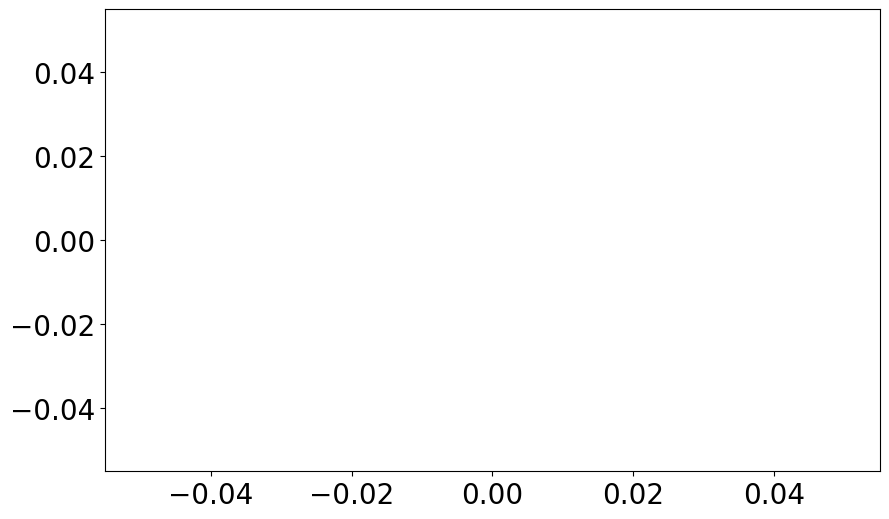

In [22]:
# Set font sizes using rcParams
plt.rcParams.update({
    'axes.titlesize': 28,
    'axes.labelsize': 25,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20
})
# Melt the DataFrame to long format
df_melted = pcc_control.melt()

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_melted['value'], bins=30, kde=True)
plt.title('PCC 4S')
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')

# Save the plot to a file
plt.savefig('../figures/pcc_control.png')

plt.show()

In [ ]:
del pcc_control

### For Mild/Moderate COVID cells (Macrophage)

In [4]:
# data_I = pd.read_csv("/hdd/edward/the-project/results/I_metacell.csv", index_col=0)
data_mild = adata[adata.obs['CoVID-19 severity'] == "mild/moderate"]
data_mild = pd.DataFrame(data_mild.layers['scvi_scale'], index=data_mild.obs_names, columns=data_mild.var_names)
data_mild

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AAACCTGCAATCCGAT-1-3-0,-0.726209,-0.484398,-0.627408,-0.345855,-0.922000,-0.245375,-1.211147,-0.754270,-0.320265,-0.567520,...,-0.236781,-0.597367,-0.296355,-0.594169,-0.052638,-0.515134,-0.609986,-0.365428,-0.311566,0.305412
AAACCTGTCACTATTC-1-3-0,-0.619270,-0.476626,-0.547702,-0.347010,-0.908552,1.819158,-0.471071,-0.828678,-0.308694,-0.513932,...,-0.821896,-0.593565,-0.272360,-0.412732,-0.557719,-0.434380,-0.476416,-0.372330,-0.312588,-0.107435
AAACCTGTCCTCCTAG-1-3-0,-0.720060,-0.472344,-0.615522,-0.363685,-0.991007,0.294392,-0.881785,-0.675907,-0.334584,-0.509157,...,-0.503421,-0.595739,-0.304588,-0.535773,-0.090471,-0.491134,-0.573040,-0.374275,-0.313421,0.121214
AAACGGGTCGCATGGC-1-3-0,-0.629262,-0.481115,-0.637948,-0.363606,-0.939926,-0.261207,-0.873880,-0.811709,-0.360100,-0.458790,...,-0.791789,-0.594670,-0.306839,-0.436405,0.301168,-0.482750,-0.604929,-0.375945,-0.314054,0.289140
AAACGGGTCGTTACAG-1-3-0,-0.676587,-0.479130,-0.421644,-0.349562,-0.634043,-0.231087,-0.956424,-0.382930,-0.324872,-0.533339,...,-0.308274,-0.584246,-0.291017,-0.538188,0.180087,-0.504031,-0.563322,0.019658,-0.112110,0.920165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTTAGCAGATAATG-98-1,-0.652824,-0.338106,-0.168596,-0.372712,-0.280375,-0.367395,0.793687,-0.615411,-0.384939,-0.509104,...,-0.817406,0.454280,-0.224906,-0.500750,0.430149,-0.331937,-0.024340,-0.177738,0.494693,-0.678702
TTGAACGTCTCTGAGA-98-1,-0.642511,-0.478779,-0.663568,-0.358942,0.715889,-0.360461,-1.303570,-0.440315,-0.387993,-0.530962,...,-0.904304,-0.149902,-0.290346,-0.493415,-0.642078,0.945456,-0.561319,-0.377015,-0.314563,-0.717036
TTGCCGTAGGAATCGC-98-1,-0.567529,0.021569,-0.408896,-0.326309,0.432870,-0.293189,0.747093,-0.306974,-0.292319,-0.182374,...,-0.785470,3.840453,-0.226884,-0.497964,0.638810,0.214567,3.803528,-0.140647,-0.270409,-0.357357
TTTATGCCATGGTAGG-98-1,-0.674787,-0.484878,-0.656974,-0.352343,0.332355,-0.343147,-1.182384,-0.778601,-0.384613,-0.543250,...,-0.898270,1.195764,-0.298936,-0.389816,-0.549123,2.644236,-0.375951,-0.376652,-0.314583,-0.533485


In [5]:
import pandas as pd
import numpy as np
from nancorrmp.nancorrmp import NaNCorrMp

pcc_mild = NaNCorrMp.calculate(data_mild, n_jobs=12)

In [6]:
pcc_mild.to_csv("pcc_mild.csv")

In [ ]:
# Melt the DataFrame to long format
df_melted = pcc_mild.melt()

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_melted['value'], bins=30, kde=True)
plt.title('PCC Mild/Moderate')
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')

# Save the plot to a file
plt.savefig('./figures/pcc_mild.png')

plt.show()

In [ ]:
del pcc_mild

### For Severe/Critical COVID cells (Macrophage)

In [4]:
# data_III = pd.read_csv("/hdd/edward/the-project/results/III_metacell.csv", index_col=0)
data_severe = adata[adata.obs['CoVID-19 severity'] == "severe/critical"]
data_severe = pd.DataFrame(data_severe.layers['scvi_scale'], index=data_severe.obs_names, columns=data_severe.var_names)
data_severe

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AAACCTGAGACTTTCG-1-6-0,-0.315027,-0.481416,0.062585,-0.366357,-0.730941,-0.282992,-0.119218,-0.006072,-0.340440,-0.491899,...,0.799428,-0.596499,-0.262735,-0.420591,0.869163,-0.522446,-0.622358,-0.364838,-0.157875,-0.131025
AAACCTGAGCATGGCA-1-6-0,-0.390763,-0.468575,0.394430,-0.371153,-0.728155,0.231286,4.372635,-0.368966,0.056005,-0.549693,...,-0.045306,-0.583536,-0.261787,-0.432976,-0.452616,-0.506024,-0.535122,0.238749,-0.253856,-0.607914
AAACCTGAGGACATTA-1-6-0,-0.382331,-0.487782,9.054833,-0.357597,-0.692595,-0.291774,0.593204,-0.059760,-0.230667,-0.497055,...,1.000142,-0.600145,-0.169760,0.127363,-0.238289,-0.524711,-0.620326,-0.321043,0.070750,-0.199543
AAACCTGAGGACTGGT-1-6-0,0.863489,-0.446704,-0.375986,-0.364006,-0.935474,-0.286806,-0.464183,-0.620511,-0.168970,-0.501546,...,-0.421609,-0.586113,-0.171363,-0.437717,-0.263135,-0.512939,-0.538902,-0.281523,-0.211462,-0.586292
AAACCTGCAAACCCAT-1-6-0,-0.435112,-0.487030,-0.188161,-0.366088,-0.850020,-0.172094,0.254325,-0.095239,-0.076235,-0.539800,...,-0.613320,-0.595425,-0.298065,-0.565438,-0.544542,-0.524552,-0.630355,-0.321334,-0.229451,-0.737022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCCTTCTTCGAGGCAA-224-1,-0.693939,0.419854,-0.637387,0.217561,0.772984,-0.334874,-0.103562,7.843357,-0.345578,0.559982,...,-0.492467,-0.452319,-0.139139,-0.561529,1.589688,-0.321540,-0.542371,-0.360109,-0.310138,-0.783015
TGAATGCCAGATCCTA-224-1,-0.721588,0.586088,-0.637849,0.354869,1.931009,0.190127,-0.281995,6.873249,-0.303346,0.126323,...,0.388764,-0.576639,-0.152095,-0.518633,3.041238,-0.376847,-0.480513,-0.364047,-0.308513,-0.774535
TTACAGGGTATGGAAT-224-1,-0.591897,2.097727,-0.344161,0.213904,2.622555,0.540497,0.730513,3.282856,-0.245019,1.330113,...,0.191392,-0.474995,-0.053657,-0.469099,4.859582,-0.077755,-0.593682,-0.291877,-0.265054,-0.716913
TTACCGCAGAGAGGGC-224-1,-0.728751,2.600402,-0.640185,-0.068430,1.078175,-0.336607,0.769835,3.134197,-0.357425,-0.177774,...,4.878139,-0.310970,-0.048686,-0.504215,-0.269736,-0.093932,-0.269155,-0.367206,-0.313424,-0.781157


In [5]:
import pandas as pd
import numpy as np
from nancorrmp.nancorrmp import NaNCorrMp

pcc_severe = NaNCorrMp.calculate(data_severe, n_jobs=12)

In [6]:
pcc_severe.to_csv("pcc_severe.csv")

In [7]:
###### Melt the DataFrame to long format
df_melted = pcc_severe.melt()

In [8]:
del pcc_severe

MemoryError: Unable to allocate 5.26 GiB for an array with shape (706018041,) and data type float64

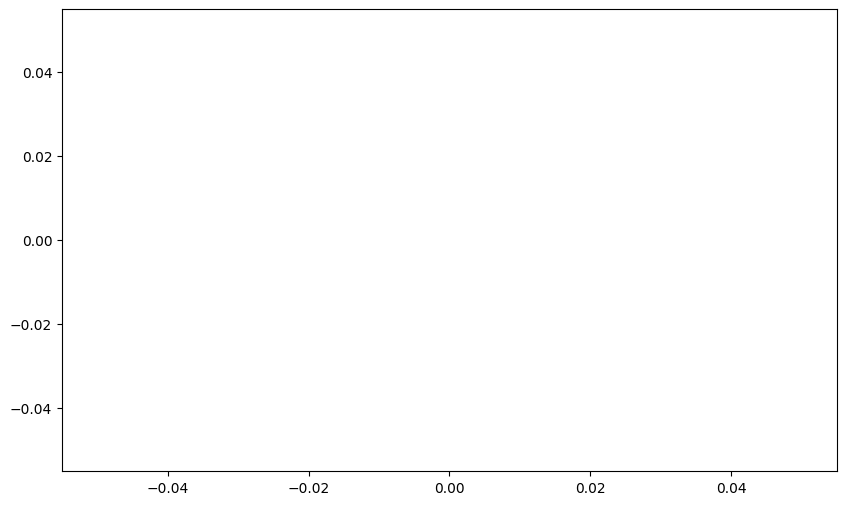

In [9]:
# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_melted['value'], bins=30, kde=True)
plt.title('PCC Severe/Critical')
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')

# Save the plot to a file
plt.savefig('./figures/pcc_severe.png')

plt.show()